In [1]:
import os
import json
import torch
from PIL import Image
from torch.utils.data import Dataset
from typing import Dict, List, Any
from transformers import AutoTokenizer, CLIPImageProcessor
from torch.amp import autocast, GradScaler
from tqdm import tqdm
from torch.nn.utils.rnn import pad_sequence

In [ ]:
class MiniLlavaDataset(Dataset):
    def __init__(self, json_path, img_dir, tokenizer, image_processor, max_length):#
        super().__init__()
        with open(json_path, 'r', encoding='utf-8') as f:
            self.annotations = json.load(f)
        self.img_dir = img_dir
        self.tokenizer = tokenizer
        self.image_processor = image_processor
        self.max_length = max_length

        self.IMAGE_TOKEN = "<img>"

    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, index):
        caption = self.annotations[index]["caption"]
        image_id = self.annotations[index]["image_id"]
        image_path = f"{self.img_dir}/COCO_train2014_{image_id:012d}.jpg"

        image = Image.open(image_path).convert("RGB")
        image_tensor = self.image_processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

        prompt_user = f"<|im_start|>user\n{self.IMAGE_TOKEN}\nDescribe this image.<|im_end|>\n<|im_start|>assistant\n"
        full_text = f"{prompt_user}{caption}<|im_end|>"

        prompt_tokens = self.tokenizer(prompt_user, allowed_special='all')["input_ids"]
        full_tokens = self.tokenizer(full_text, allowed_special='all', max_length = self.max_length, truncation=True)["input_ids"]

        input_ids = torch.tensor(full_tokens, dtype=torch.long)

        labels = input_ids.clone()
        labels[:len(prompt_tokens)] = -100

        return {
            "input_ids": input_ids,
            "labels": labels,
            "image_tensor": image_tensor,
            "image_path":image_path,
            "caption": caption
        }

In [3]:
class LLaVADataCollator: 
    def __init__(self, pad_token_id):
        self.pad_token_id = pad_token_id

    def __call__(self, batch):
        input_ids = [item["input_ids"] for item in batch]
        labels = [item["labels"] for item in batch]
        images = [item["image_tensor"] for item in batch]

        input_ids_pad = pad_sequence(sequences=input_ids, batch_first=True, padding_value=self.pad_token_id)

        labels_padded = pad_sequence(labels, True, padding_value=-100)

        images_stack = torch.stack(images)

        return {
            "input_ids": input_ids_pad,
            "labels": labels_padded,
            "image_tensor": images_stack 
        }




In [ ]:
img_test = "COCO_train2014_000000000009.jpg"
image = Image.open(img_test)
processor = CLIPImageProcessor.from_pretrained("openai/clip-vit-base-patch16")  #openai/clip-vit-large-patch14-336
image_tensor = processor(images=image)
image_tensor['pixel_values'][0][0][0][1]

In [4]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct") #Qwen/Qwen2.5-1.5B-Instruct
tokenizer.add_tokens(["<img>"], special_tokens=True)

image_processor = CLIPImageProcessor.from_pretrained("openai/clip-vit-base-patch16")  #openai/clip-vit-large-patch14-336

dataset = MiniLlavaDataset("/kaggle/input/datasets/nagasai524/mini-coco2014-dataset-for-image-captioning/captions.json", 
                           "/kaggle/input/datasets/nagasai524/mini-coco2014-dataset-for-image-captioning/Images",
                           tokenizer, image_processor, max_length=128)

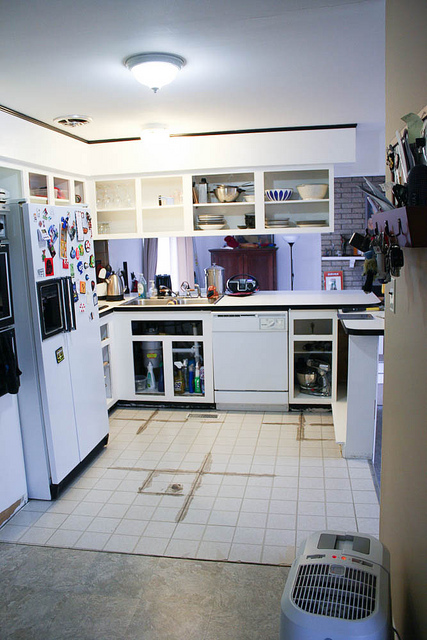

A white square kitchen with tile floor that needs repairs 


(tensor([151644,    872,    198, 151665,    198,  74785,    419,   2168,     13,
         151645,    198, 151644,  77091,    198,     32,   4158,   9334,   9780,
            448,  10023,   6422,    429,   3880,  30186,    220, 151645]),
 tensor([  -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
           -100,   -100,   -100,   -100,   -100,     32,   4158,   9334,   9780,
            448,  10023,   6422,    429,   3880,  30186,    220, 151645]),
 tensor([-0.3032, -0.3324]))

In [5]:
from IPython.display import display
sample = dataset[0]

img = Image.open(sample["image_path"]).convert("RGB")
display(img)
print(sample['caption'])
sample['input_ids'], sample['labels'], sample['image_tensor'][0][0][:2]

In [6]:
class LLaVAMLP(torch.nn.Module):
    def __init__(self, vision_dim, text_dim):
        super().__init__()
        self.linear_1 = torch.nn.Linear(vision_dim, text_dim, bias=True)
        self.act = torch.nn.GELU()
        self.linear_2 = torch.nn.Linear(text_dim, text_dim, bias=True)

    def forward(self, image_features):
        return self.linear_2(self.act(self.linear_1(image_features)))

In [7]:
class LLaVA(torch.nn.Module):
    def __init__(self, vision_module, llm_module, mlp_module):
        super().__init__()
        self.vision_module = vision_module
        self.llm_module = llm_module
        self.mlp_module = mlp_module

        self.IMAGE_TOKEN_ID = None

    def forward(self, input_ids, image_tensor, labels):
        text_embs = self.llm_module.model.embed_tokens(input_ids)

        with torch.no_grad():
            image_out = self.vision_module(image_tensor, output_hidden_states=True)
            # image_features = image_out.last_hidden_state[-2][:, 1:] 
            image_features = image_out.hidden_states[-2][:, 1:] # from article, last hidden state its better then last state, cause last state focus on [cls] token in general


        image_embs = self.mlp_module(image_features) #[b, num_putch, hid_state]

        B, seq_len = input_ids.shape
        num_patches = image_embs.shape[1] #[b, num putches, hid_state]
        final_len = seq_len - 1 + num_patches # -1 cause replace <img> token on img describe embs
        D = text_embs.shape[-1]



        image_positions = (input_ids == self.IMAGE_TOKEN_ID).nonzero(as_tuple=True)[1]

        model_grid = torch.arange(final_len, device=input_ids.device).unsqueeze(0).repeat(B, 1)
        src_grid = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).repeat(B, 1)

        image_start_pos = image_positions.unsqueeze(1)
        image_end_pos = image_start_pos + num_patches

        is_img_dst = (image_start_pos <= model_grid) & (model_grid < image_end_pos)
        txt_before_dst = model_grid < image_start_pos # begore img part
        txt_after_dst = image_end_pos <= model_grid # after img part

        txt_before_src = src_grid < image_start_pos #before <img> token
        txt_after_src = src_grid > image_start_pos #after <img> token

        final_embs = torch.zeros(B, final_len, D, dtype=text_embs.dtype, device=text_embs.device)
        final_labels = torch.full((B, final_len), -100, dtype=labels.dtype, device=labels.device)

        final_embs[is_img_dst] = image_embs.to(final_embs.dtype).view(-1, D)
        final_embs[txt_before_dst] = text_embs[txt_before_src]
        final_embs[txt_after_dst] = text_embs[txt_after_src]

        final_labels[txt_before_dst] = labels[txt_before_src] # cause of all dialog is included in one time, we need to consider in labels part with model answer before 
        # exmp
        # - hello -hello, what can i help -whats on this pict <img> -on this pict i see a dog
        #   -100    67     52  42  69 18  -100 -100 -100 -100  -100   1.  2.   3. 4. 5. 6. 1
        final_labels[txt_after_dst] = labels[txt_after_src]

        outputs = self.llm_module(
            inputs_embeds=final_embs,
            labels = final_labels,
            return_dict = True,
            use_cache=False
        )
        
        return outputs.loss

In [8]:
def train_epoch(
        model, dataloader, optimizer, scheduler, device, 
        gradient_accumulation_steps=4, 
        max_grad_norm=1.0,
        use_bfloat16=True
    ):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    dtype = torch.bfloat16 if use_bfloat16 else torch.float16

    scaler = GradScaler(device='cuda', enabled= not use_bfloat16)

    pbar = tqdm(dataloader, desc="Training")
    for step, batch in enumerate(pbar):
        input_ids = batch["input_ids"].to(device)
        image_tensor = batch["image_tensor"].to(device)
        labels = batch["labels"].to(device)

        # for mixed precision (hard operation - float16, high precision operation - float32)
        with autocast(device_type='cuda', dtype=dtype):
            loss = model(input_ids = input_ids, image_tensor=image_tensor, labels=labels)
            loss = loss/gradient_accumulation_steps

        scaler.scale(loss).backward()
        total_loss += loss.item() * gradient_accumulation_steps
        
        if (step + 1) % gradient_accumulation_steps == 0 or (step + 1) == len(dataloader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm) # grad explosion protect

            scaler.step(optimizer)
            scaler.update()
            
            if scheduler is not None: scheduler.step()
            
            optimizer.zero_grad()
        
        pbar.set_postfix({"loss": loss.item() * gradient_accumulation_steps})

    return total_loss/len(dataloader)

In [9]:
# from transformers import TrainingArguments, Trainer

# training_args = TrainingArguments(
#     output_dir="./llava_checkpoints",
#     learning_rate=2e-5,              
#     per_device_train_batch_size=2,   
#     gradient_accumulation_steps=4,   
    
#     bf16=True,
#     max_grad_norm=1.0,
    
#     logging_steps=10, 
#     num_train_epochs=3,
#     remove_unused_columns=False
# )

# trainer = Trainer(
#     model=model,                            
#     args=training_args,                     
#     train_dataset=my_custom_dataset,        
#     data_collator=my_data_collator,         
# )

# trainer.train()

In [ ]:
from transformers import AutoModelForCausalLM, CLIPVisionModel
from torch.utils.data import DataLoader

def main():
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"device is {DEVICE}")
    EPOCHS = 3
    BATCH_SIZE = 8
    GRAD_ACC_STEPS = 2

    VISION_DIM = 768
    TEXT_DIM = 896

    llm_module = AutoModelForCausalLM.from_pretrained(
        "Qwen/Qwen2.5-0.5B-Instruct", 
        torch_dtype=torch.float16
    )
    llm_module.resize_token_embeddings(len(tokenizer))
    llm_module.gradient_checkpointing_enable()

    vision_module = CLIPVisionModel.from_pretrained(
        "openai/clip-vit-base-patch16", 
        torch_dtype=torch.float16
    )

    mlp_module = LLaVAMLP(vision_dim=VISION_DIM, text_dim=TEXT_DIM)
    mlp_ckpt_path = "checkpoints/llava_mlp_epoch_1.pth"
    state = torch.load(mlp_ckpt_path, map_location="cuda" if torch.cuda.is_available() else "cpu")
    mlp_module.load_state_dict(state)

    model = LLaVA(vision_module, llm_module, mlp_module)

    model.IMAGE_TOKEN_ID = tokenizer.convert_tokens_to_ids("<img>")
    model.to(DEVICE)

    for param in model.vision_module.parameters():
        param.requires_grad = False

    for param in model.llm_module.parameters():
        param.requires_grad = False

    for param in model.mlp_module.parameters():
        param.requires_grad = True

    print(f"train params: {sum(par.numel() for par in model.parameters() if par.requires_grad)}")

    collator = LLaVADataCollator(tokenizer.pad_token_id)

    dataloader = DataLoader(
        dataset, BATCH_SIZE, shuffle=True, collate_fn=collator,
        num_workers=2,       
        pin_memory=True,     
        drop_last=True
    )

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=1e-3, 
        weight_decay=0.1
    )

    os.makedirs("checkpoints", exist_ok=True)
    loss_log_path = "checkpoints/loss_log.txt"

    for epoch in range(EPOCHS):
        print(f"epoch {epoch+1}/{EPOCHS}")

        loss = train_epoch(
            model, 
            dataloader, 
            optimizer,
            scheduler=None,
            device=DEVICE,
            gradient_accumulation_steps=GRAD_ACC_STEPS,
            use_bfloat16=False
        )
        print(f"loss: {loss}")
        with open(loss_log_path, "a", encoding="utf-8") as f:
            f.write(f"epoch {epoch+1}/{EPOCHS}: {loss}\n")

        torch.save(
            model.mlp_module.state_dict(), 
            f"checkpoints/llava_mlp_epoch_{epoch + 1}.pth"
        )
        print(f"checkpoint saved")

In [13]:
main()

device is cuda


device is cuda


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

device is cuda


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.wei

train params: 1492736
epoch 1/3


Training:   2%|▏         | 714/46975 [02:14<2:25:42,  5.29it/s, loss=2.19]


KeyboardInterrupt: 